# T29 — A Phanerozoic apparent polar wander path draped on reconstructed Laurentia

**Plot the Torsvik et al. (2012) Laurentia apparent polar wander path as a track of coloured-by-age poles, but with each pole rendered on a Laurentia that has been reconstructed to that pole's age — so the pole and the host continent travel together through the Phanerozoic.**

## What this notebook produces

The standard way to look at an apparent polar wander path is to plot all the poles in the present-day reference frame: a single static map with the Laurentian APWP unfolding from southern hemisphere positions in the Cambrian to its present-day polar position over 500 Myr. That works because the rocks haven't moved relative to the craton, even if the craton has moved relative to the spin axis.

This notebook instead plots the APWP on a **reconstructed** Laurentia. At each pole's age we reconstruct the Laurentian continental outline to that age, plot the outline in light grey, and over-plot the contemporaneous APWP pole as a coloured circle. The result, animated as a Panel slider through 500 Ma, makes a different point: the pole and the continent are both moving relative to the spin axis, and what the rocks record is the *relative* configuration.

We use the Torsvik et al. (2012) South African–referenced Laurentian APWP bundled with this tutorial under `data/paleomag/torsvik2012_laurentia_apwp.csv` (compiled from their Table S1) and the Zahirovic 2022 plate model.

**Audience**: undergrad → postgrad.
**Difficulty**: ★★☆.

## Learning objectives

- Read an apparent polar wander path from a CSV table of (age, pole_lon, pole_lat, A95).
- Reconstruct a craton outline to an arbitrary age and pyGMT-render it as a paleo-Earth background.
- Loop reconstruction time and APWP age together to produce one paleo-frame per pole.
- Wrap the result in a Panel slider that lets the user scrub through the Phanerozoic.

## Prerequisites and runtime

- Plate model: Zahirovic 2022 (0–410 Ma covers most of the Phanerozoic; Laurentian APWP is restricted to that interval here).
- Bundled data: `data/paleomag/torsvik2012_laurentia_apwp.csv`.
- Python: `gplately`, `pygmt`, `pygplates`, `pandas`, `panel`.
- Runtime: ~1 minute for the static panels; the slider pre-renders each frame as a PNG cache (~3 s per frame).

In [1]:
# Defensive cwd fix: when Jupyter runs this notebook from Notebooks/, the
# `data/...` relative paths used below would not resolve. Step up to the
# suite root once so every `data/...` literal in the rest of the notebook
# finds its file. Idempotent — only runs if `../data` exists and `./data`
# doesn't.
import os as _os
from pathlib import Path as _Path
if _Path("../data").exists() and not _Path("data").exists():
    _os.chdir("..")

# Cell 1 — imports
import numpy as np
import pandas as pd
import gplately
import pygmt
import pygplates
from plate_model_manager import PlateModelManager
import panel as pn
from IPython.display import display, HTML
pn.extension()
# Library versions (printed for reproducibility)
try:
    import gplately, pygmt, pygplates
    print(f"gplately {gplately.__version__}  pygmt {pygmt.__version__}  pygplates {pygplates.__version__}")
except Exception as _e:
    print(f"version probe failed: {_e}")


gplately 2.0.0.post19+git.2cce7bb3  pygmt v0.18.0  pygplates 1.0.0


## Configuration — change the APWP CSV + plate model here

In [2]:
# === USER CONFIGURATION =====================================================
MODEL_NAME    = "Zahirovic2022"
APWP_CSV      = "data/paleomag/torsvik2012_laurentia_apwp.csv"
LAURENTIA_PID = 101                     # plate id for Laurentia / North America
AGES_TO_RENDER = (0, 50, 150, 300, 400) # static-panel ages for the four-panel summary
# ============================================================================


## 1. Load the APWP table

A CSV with columns `age` (Ma), `pole_lat`, `pole_lon`, `A95` (degrees).

In [3]:
# Cell 2 — load APWP
apwp = pd.read_csv(APWP_CSV, comment="#")
print(f"loaded {len(apwp)} APWP poles")
apwp.head()


loaded 41 APWP poles


,age,pole_lat,pole_lon,A95
0,0,88.4,0.0,1.5
1,10,87.5,10.0,2.0
2,20,85.0,20.0,2.2
3,30,82.5,15.0,2.8
4,40,80.0,10.0,3.0


## 2. Load the plate model + reconstruction

In [4]:
# Cell 3 — load model
pmm   = PlateModelManager()
model = pmm.get_model(MODEL_NAME, data_dir="./gplately_data")
recon = gplately.PlateReconstruction(
    rotation_model=model.get_rotation_model(),
    topology_features=model.get_topologies(),
    static_polygons=model.get_static_polygons(),
)
engine = gplately.PygmtPlotEngine()


## 3. Render one paleo-Earth panel per snapshot

For each age, reconstruct Laurentia to that age and over-plot the APWP poles up to and including that age, coloured by their own age (older = redder).


=== 0 Ma ===


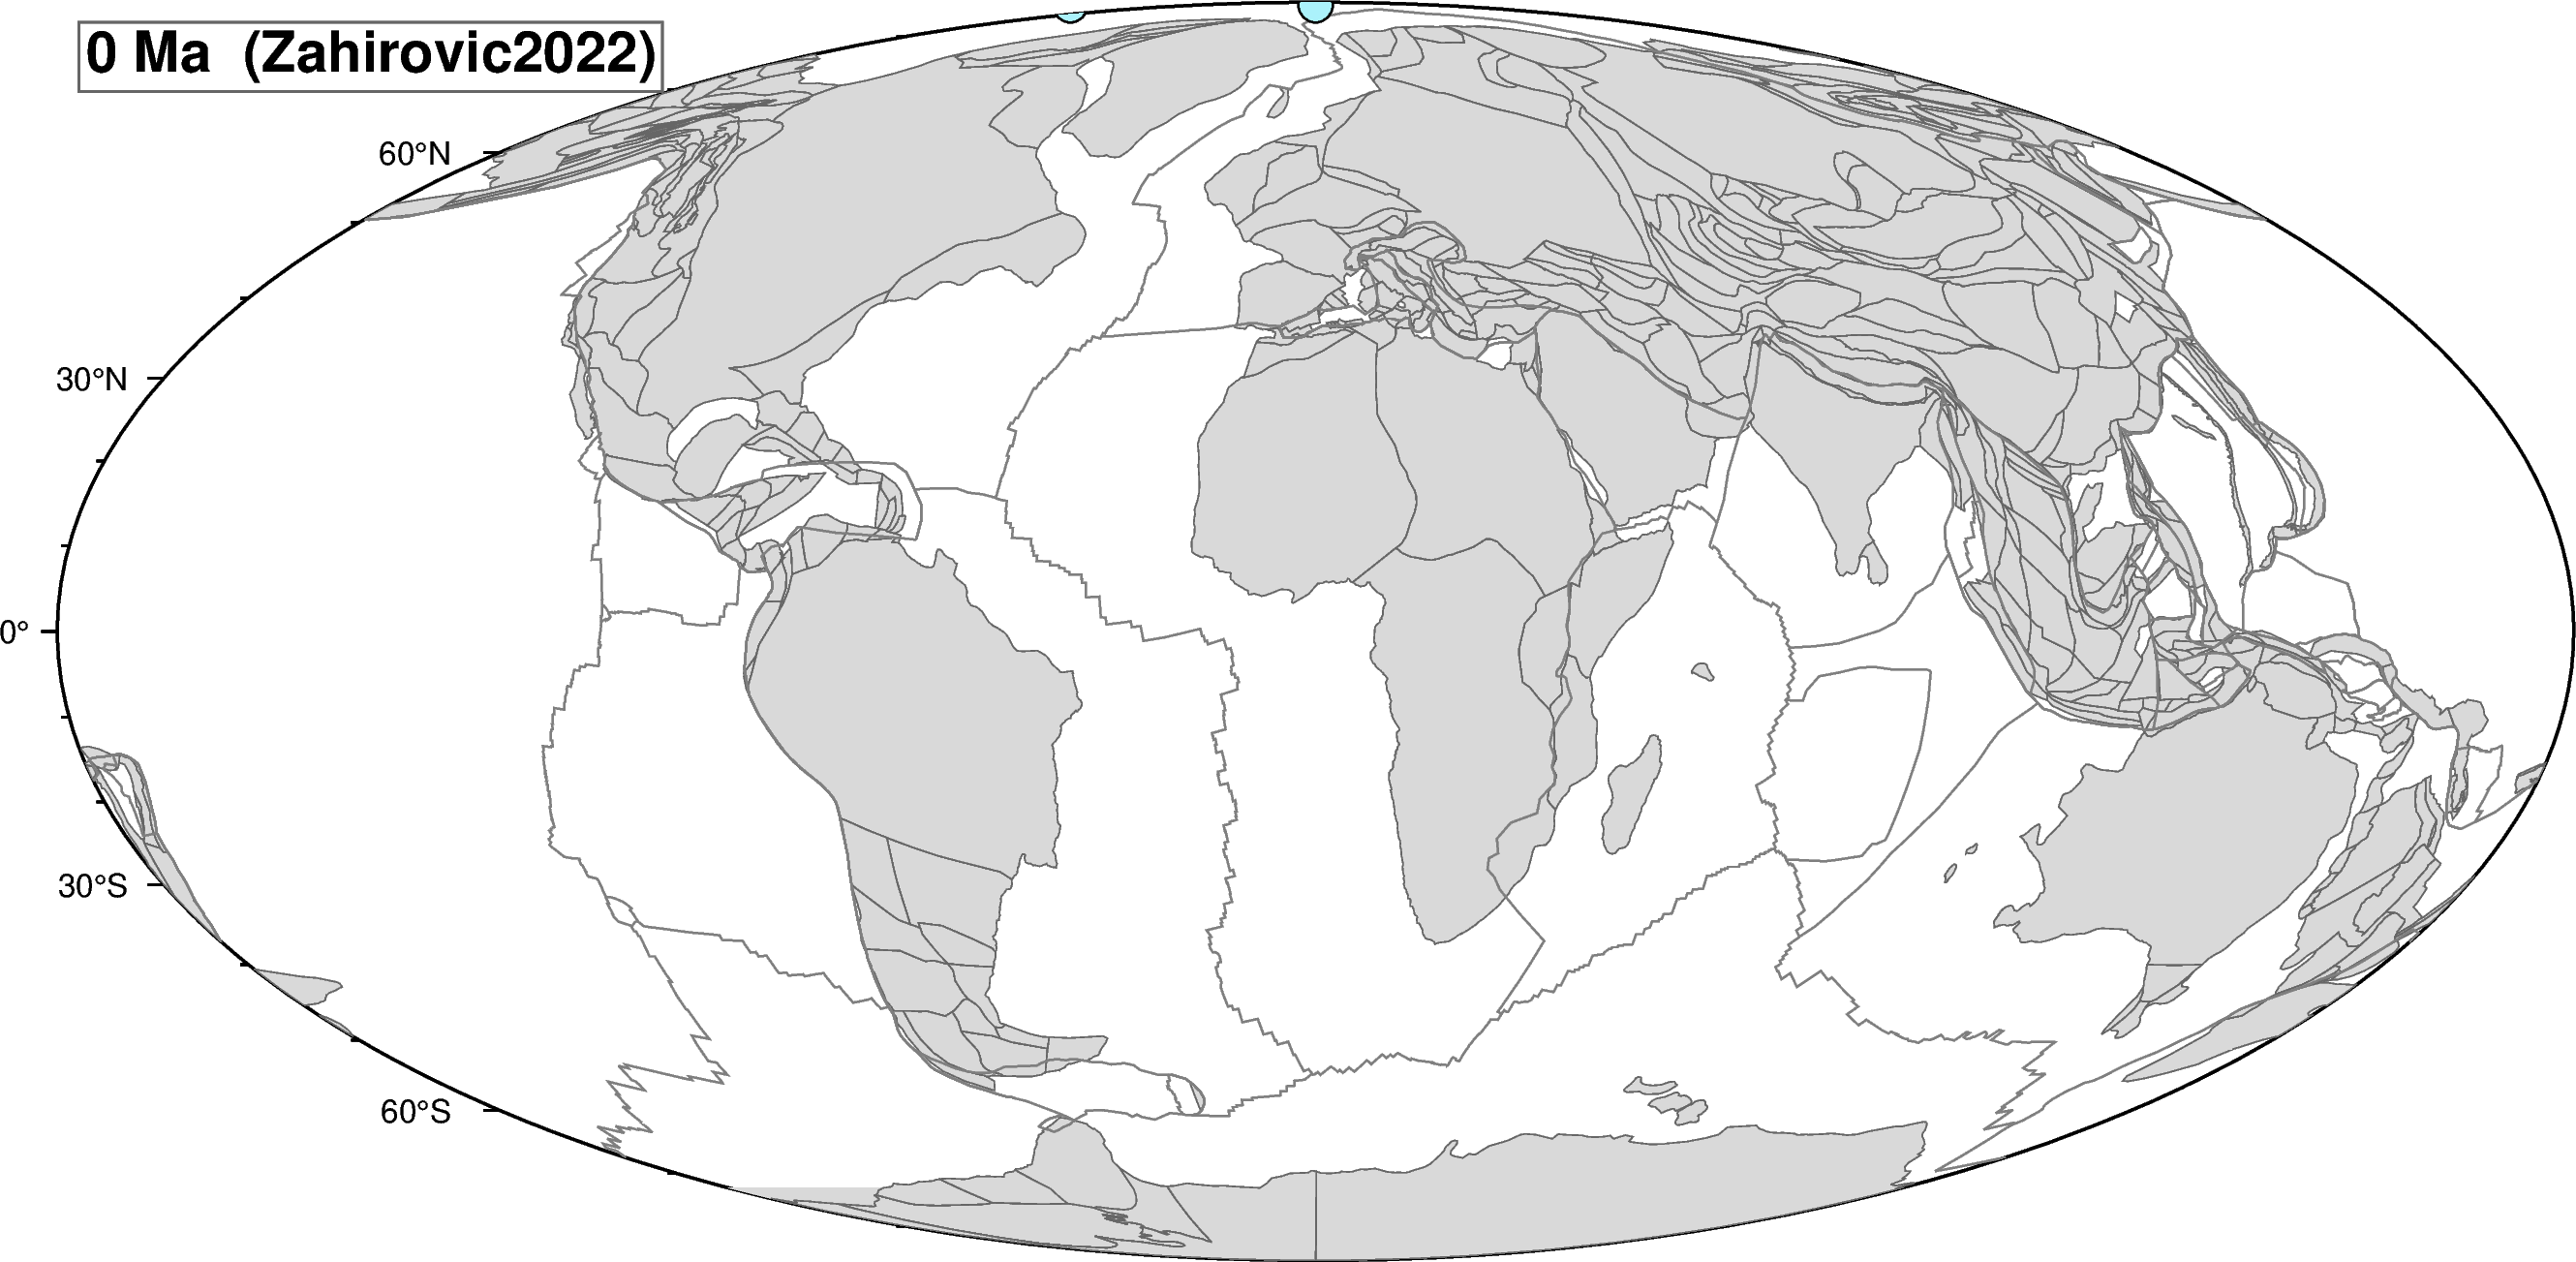


=== 50 Ma ===


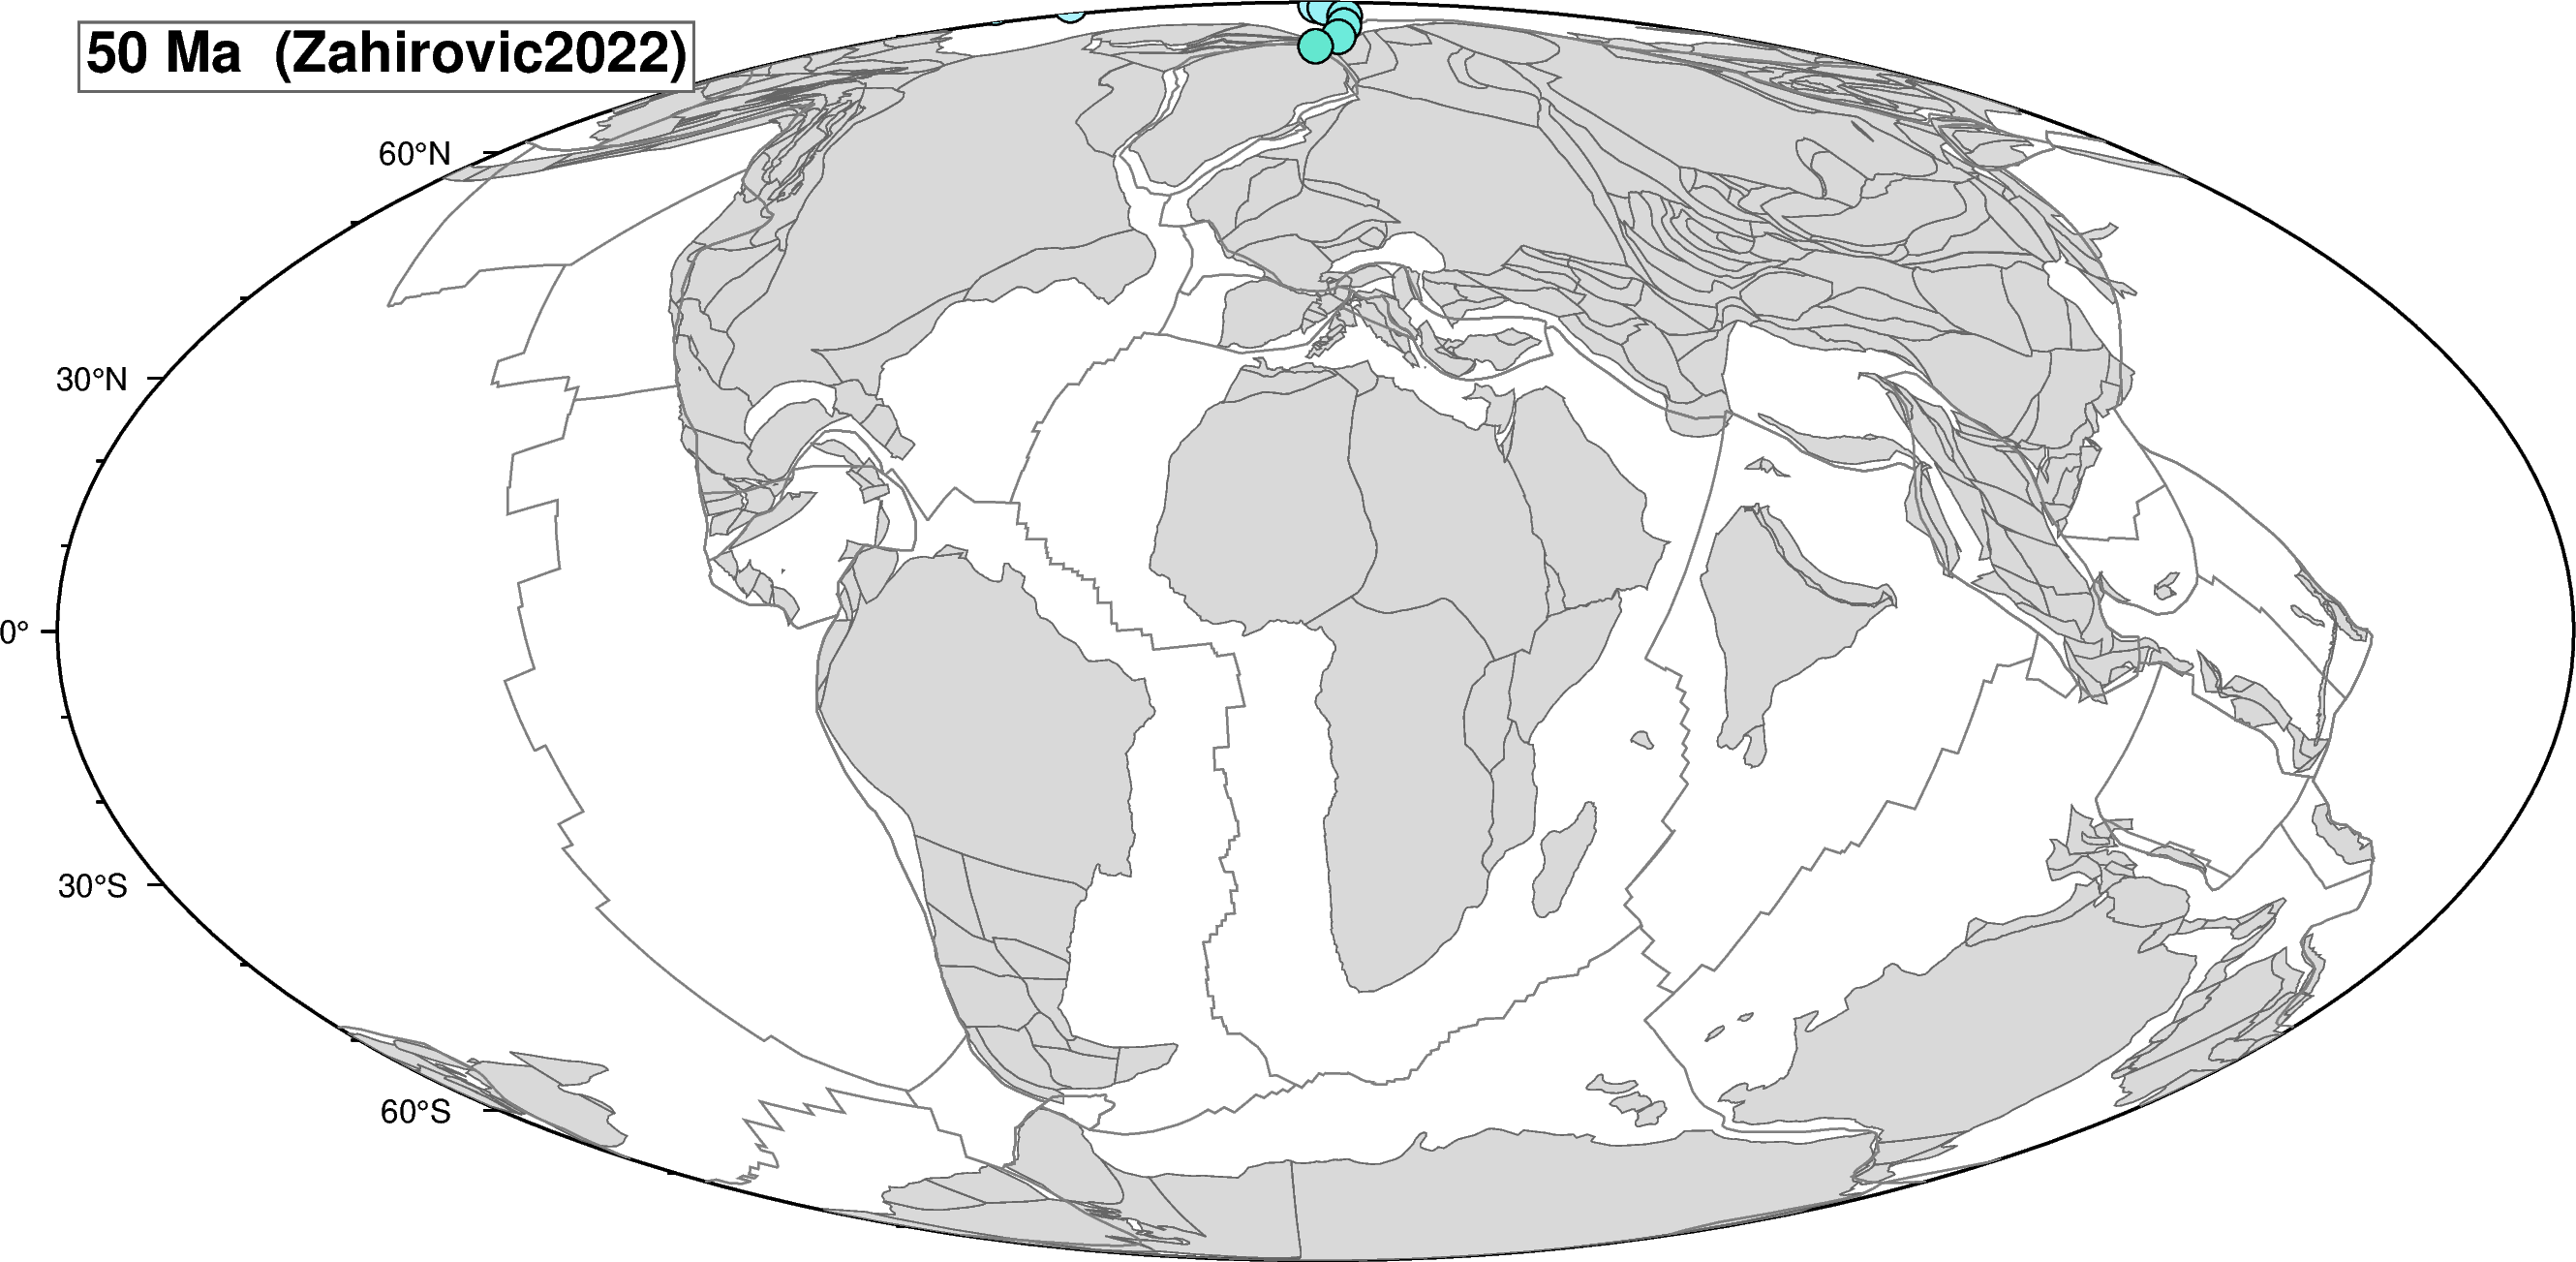


=== 150 Ma ===


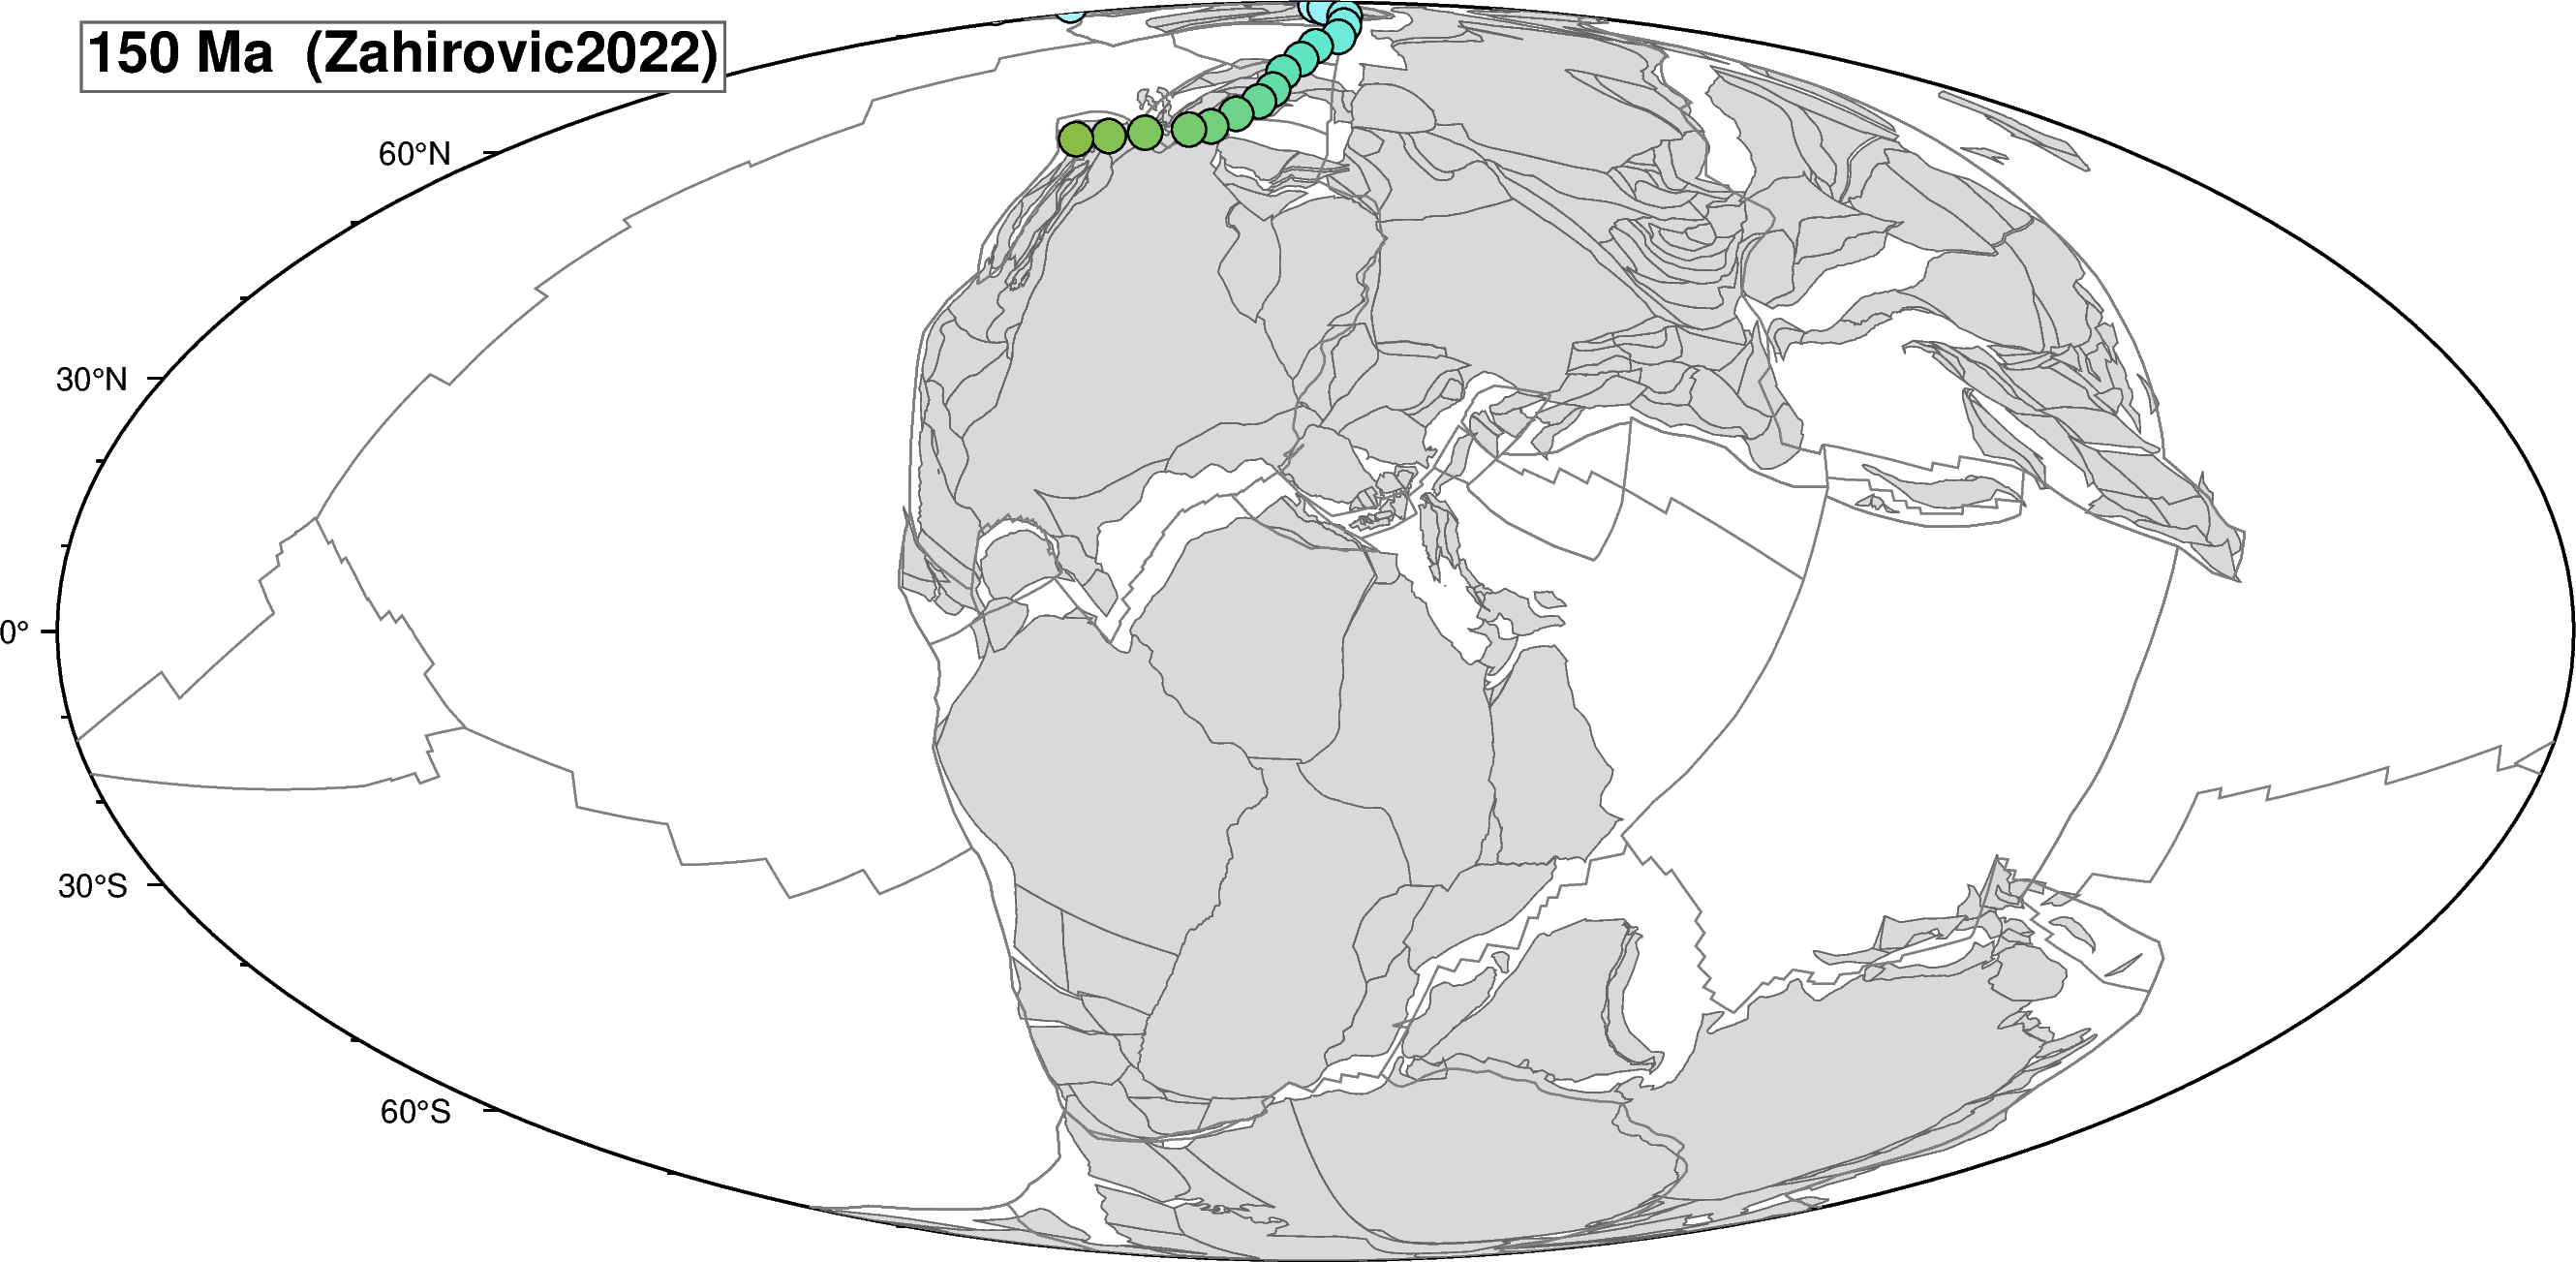


=== 300 Ma ===


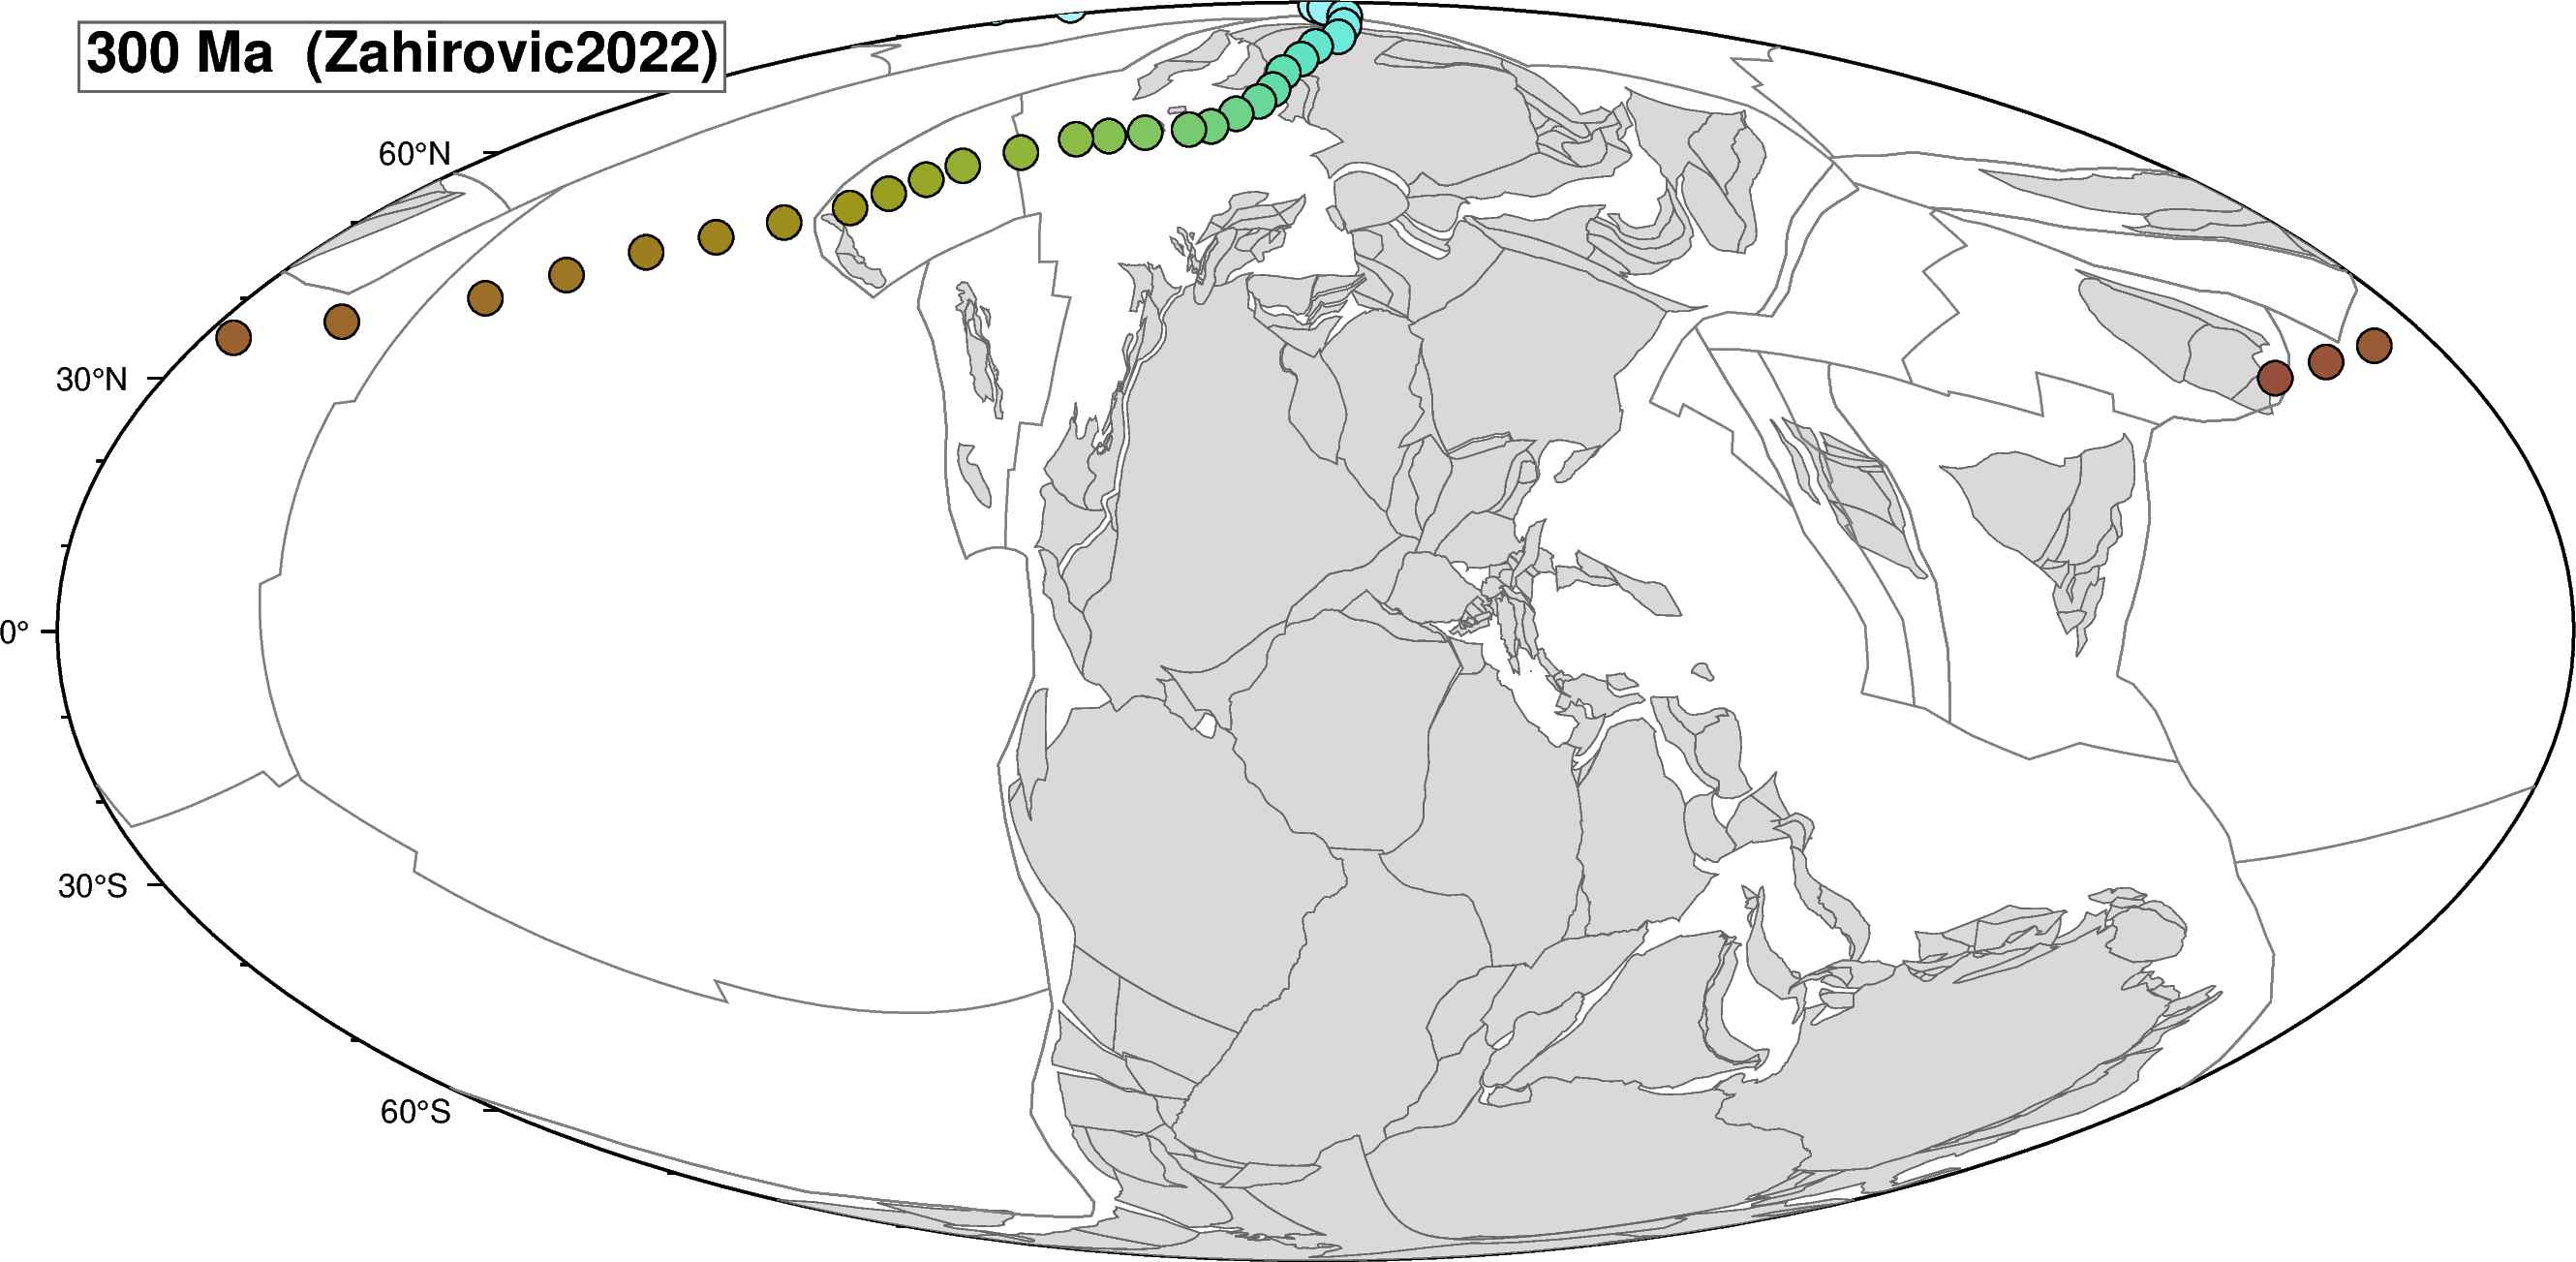


=== 400 Ma ===


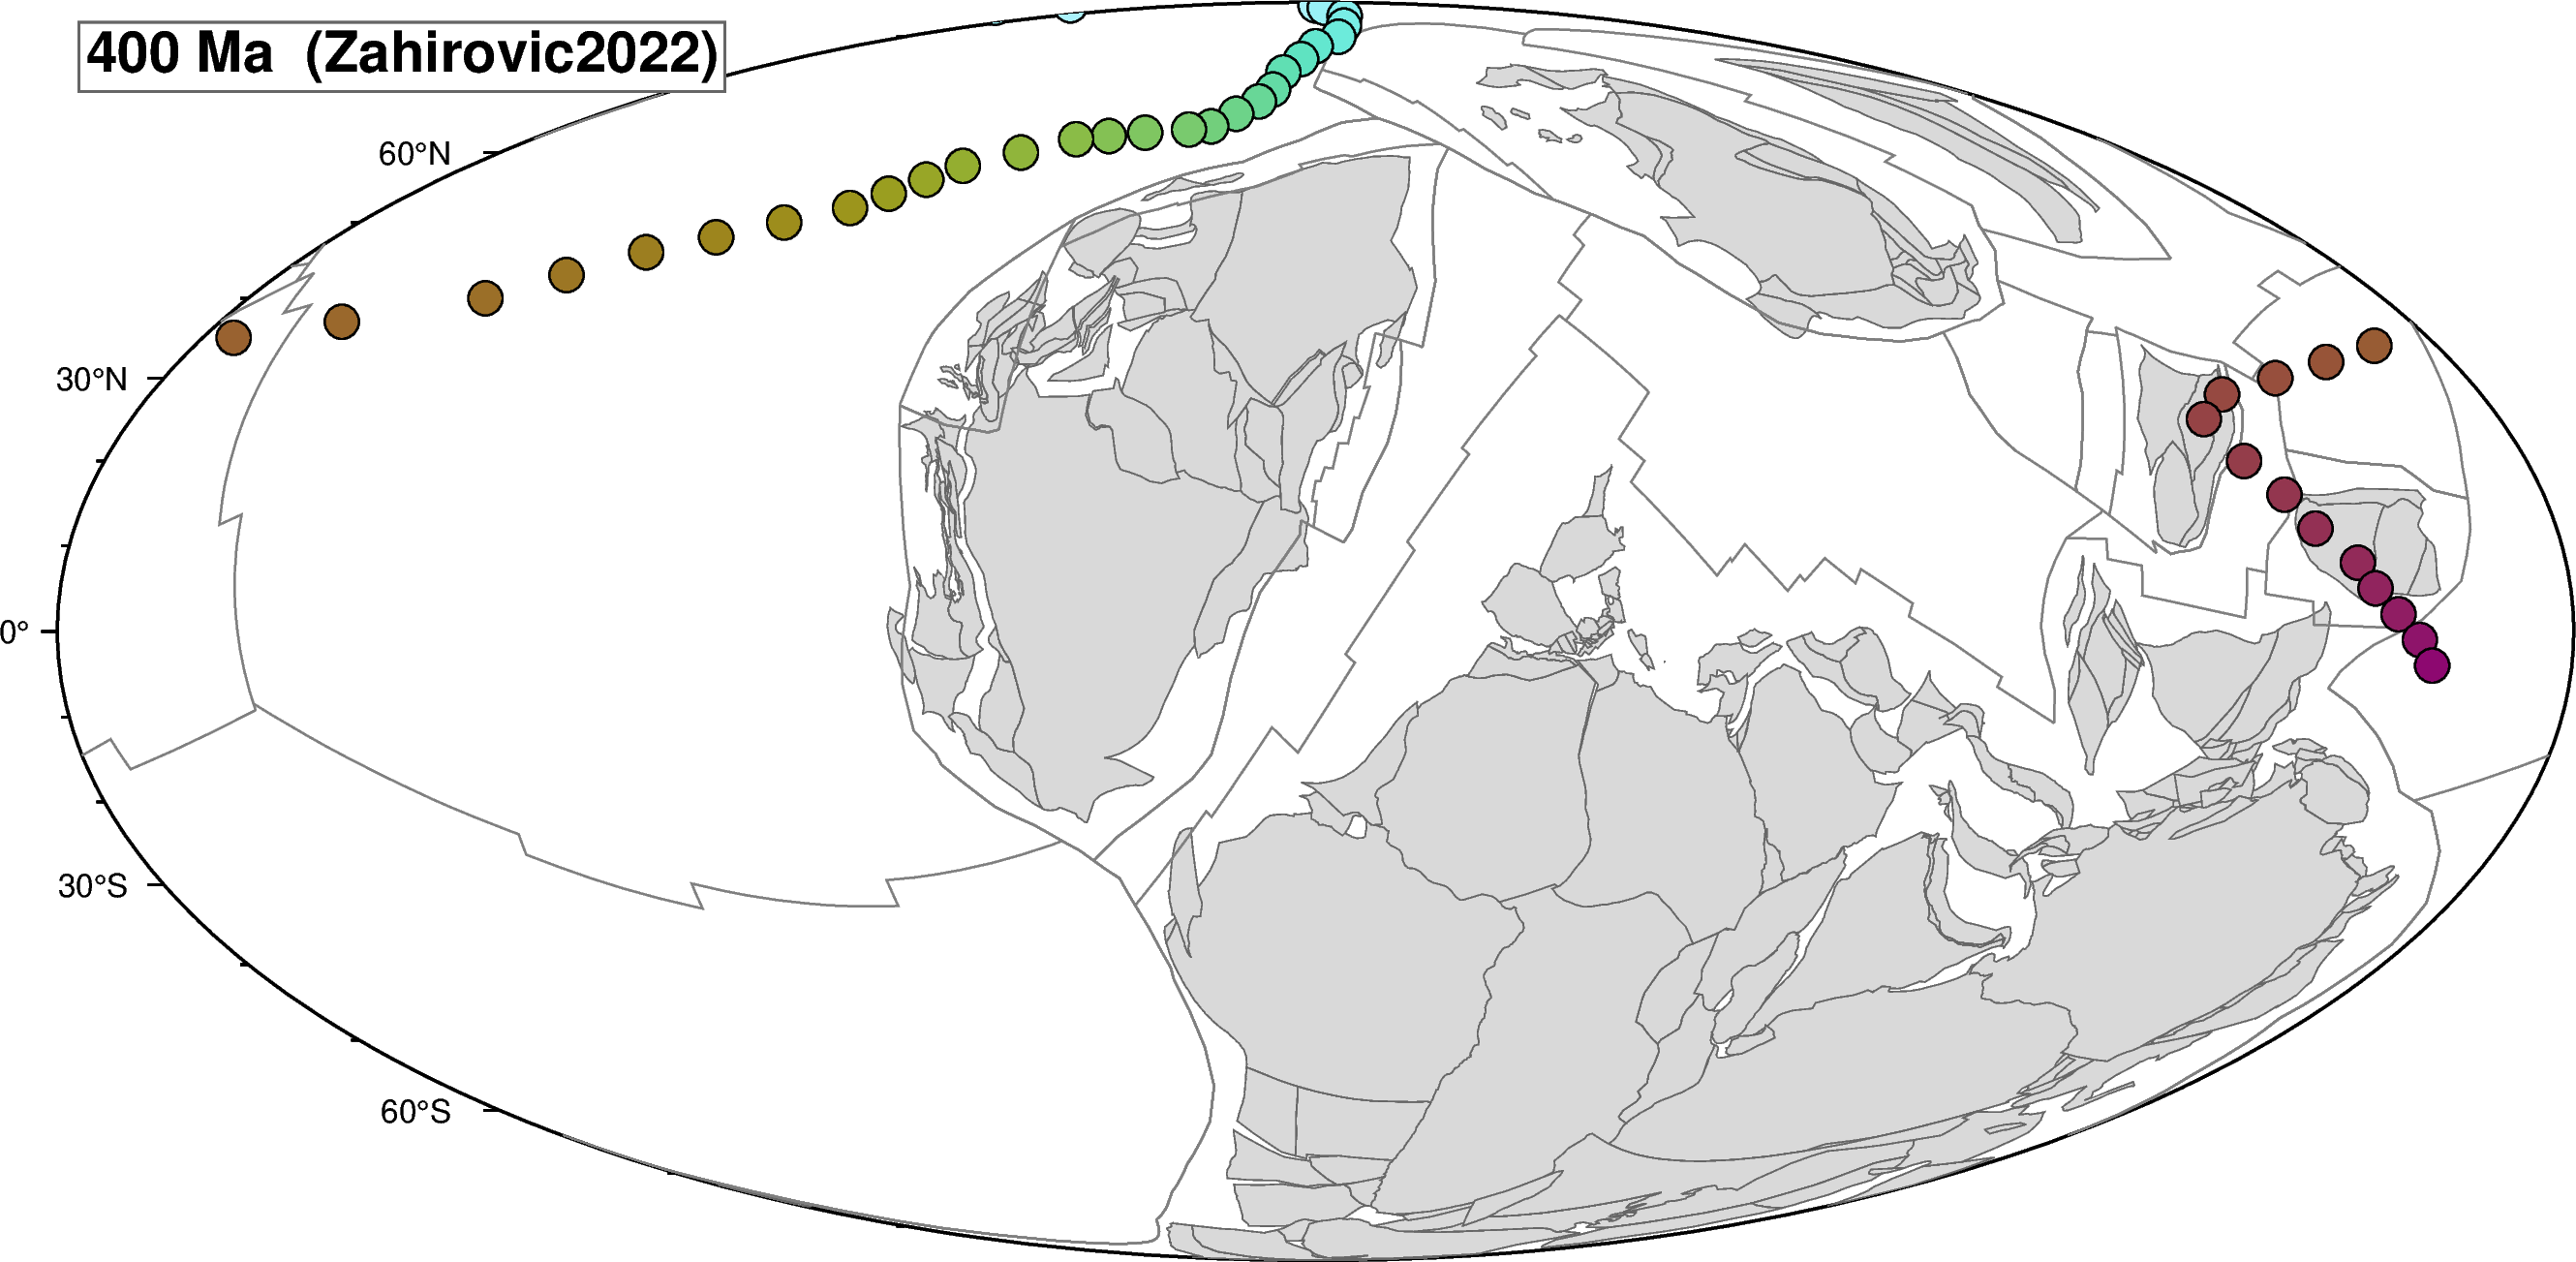

In [5]:
# Cell 4 — paleo-Earth panel renderer
def render_apwp_panel(t):
    gplot = gplately.PlotTopologies(
        plate_reconstruction=recon,
        coastlines=model.get_coastlines(),
        continents=model.get_continental_polygons(),
        COBs=model.get_COBs(),
        time=float(t),
    )
    visible = apwp[apwp["age"] <= t].copy()

    fig = pygmt.Figure()
    fig.basemap(region="d", projection="W0/22c", frame=["af"])
    engine.plot_geo_data_frame(fig, gplot.get_continents(),
                               fill="gray85", pen="0.3p,gray40")
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen="0.5p,gray50")

    if len(visible) > 0:
        pygmt.makecpt(cmap="hawaii", series=[0, 410, 10], reverse=True)
        fig.plot(x=visible["pole_lon"], y=visible["pole_lat"],
                 style="c0.30c", fill=visible["age"], cmap=True,
                 pen="0.5p,black")

    fig.text(text=f"{t:.0f} Ma  ({MODEL_NAME})",
             position="TL", offset="0.25c/-0.25c", justify="TL",
             font="14p,Helvetica-Bold,black",
             fill="white", pen="0.6p,gray40")
    return fig

# Render five static panels at AGES_TO_RENDER
for t in AGES_TO_RENDER:
    print(f"\n=== {t} Ma ===")
    fig = render_apwp_panel(t)
    fig.show(width=1100)
    display(HTML('<div style="height:1cm"></div>'))


## 4. Panel slider — scrub through the Phanerozoic

Row
    [0] IntSlider(end=410, label='Reconstruction t..., name='Reconstruction t..., step=10)
    [1] ParamFunction(function, _pane=PNG, defer_load=False)
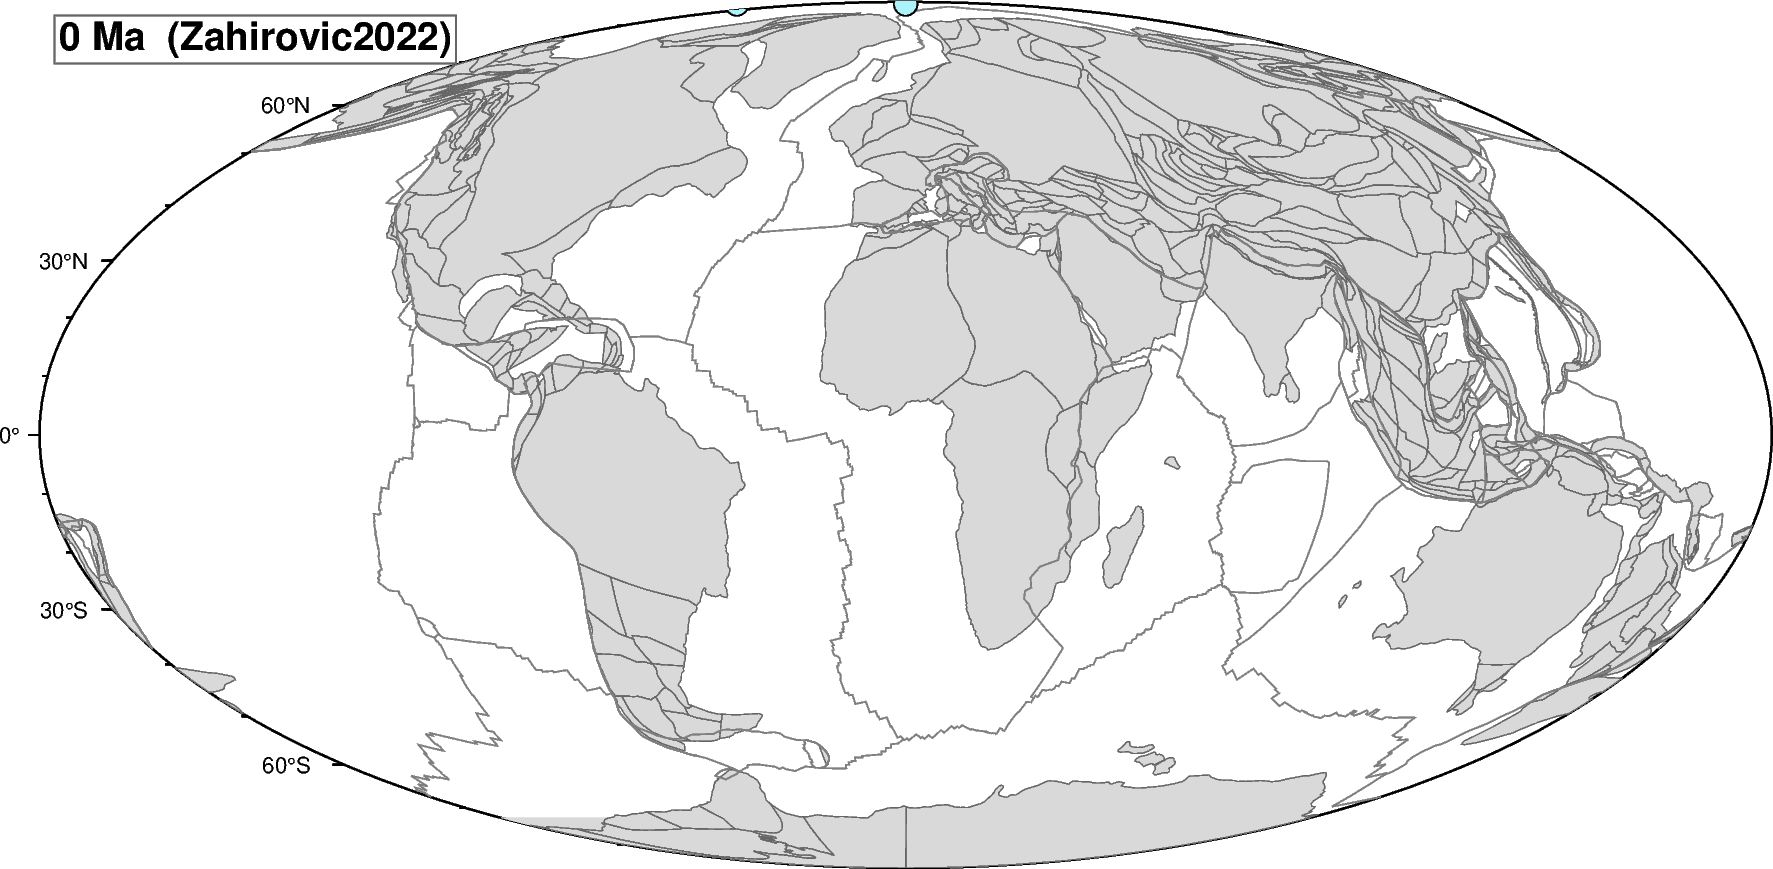

In [6]:
# Cell 5 — Panel slider
def panel_view(t):
    fig = render_apwp_panel(t)
    out = "panel_cache/apwp_{:03d}.png".format(int(t))
    import os; os.makedirs("panel_cache", exist_ok=True)
    fig.savefig(out, dpi=200)
    return pn.pane.PNG(out, width=900)

slider = pn.widgets.IntSlider(name="Reconstruction time (Ma)",
                              start=0, end=410, step=10, value=0)
dashboard = pn.Row(slider, pn.bind(panel_view, t=slider))
dashboard


## Extend this

- **Other cratons.** Repeat for Baltica (`PLATE_ID = 301`), Gondwana, or Siberia. Each craton has its own published APWP and each is supported by Zahirovic 2022 for most of the Phanerozoic.
- **Compare published APWPs.** Plot Torsvik 2012 vs Domeier & Torsvik 2017 vs Wu et al. 2021 for the same craton. Differences between the curves bound the published uncertainty on the APWP itself.
- **Cross-reference with T24/T25.** T24 builds a new APWP from the GPMDB (https://www.earth.northwestern.edu/~amir/gpmdb/). Use this notebook's panel renderer to compare T24's APWP against the Torsvik 2012 compilation it implicitly tries to reproduce.
- **Animate to MP4.** Loop the renderer over all ages 0–410 in 5 Ma steps and stitch with ffmpeg (recipe in T06).

## References

- Torsvik, T.H., Van der Voo, R., Preeden, U., Mac Niocaill, C., Steinberger, B., Doubrovine, P.V., et al. (2012). Phanerozoic polar wander, palaeogeography and dynamics. *Earth-Science Reviews* 114, 325–368.
- Mather, B.R. et al. (2024). Deep time spatio-temporal data analysis using GPlately. *Geoscience Data Journal* 11, 3–10.
- Zahirovic, S. et al. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal*.
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Tong, J.-H., Ngo, L., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J. & Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.10578540
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochemistry, Geophysics, Geosystems* 20(11), 5556–5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing plate reconstruction models. *Journal of Open Source Software* 9(101), 7090. https://doi.org/10.21105/joss.07090
